# **CNNs**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#Load CIFAR-10 and set up transforms

# CIFAR-10 known channel-wise mean/std (precomputed constants from the dataset)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # random crop with padding = augmentation
    transforms.RandomHorizontalFlip(),      # 50% chance of flipping image left-right
    transforms.ToTensor(),                  # converts PIL image to tensor, scales to [0,1]
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Load the full 50,000-image training set TWICE:
# once with augmentation (for the actual training subset),
# once without (for the validation subset) — so validation looks like real eval data
full_train_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=True, transform=train_transform)
full_train_plain = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True, transform=test_transform)

# Load the untouched 10,000-image test set
test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

# Create one shared random split: 45,000 train / 5,000 validation
generator = torch.Generator().manual_seed(42)   # seed = reproducible split every run
indices = torch.randperm(50000, generator=generator).tolist()
train_indices, val_indices = indices[:45000], indices[45000:]

train_set = Subset(full_train_aug, train_indices)     # augmented images, used for training
val_set = Subset(full_train_plain, val_indices)       # clean images, used for validation

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Train size: {len(train_set)}, Val size: {len(val_set)}, Test size: {len(test_set)}")

100%|██████████| 170M/170M [27:08<00:00, 105kB/s]


Train size: 45000, Val size: 5000, Test size: 10000


In [ ]:
#defining the scratch CNN:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1: 32x32x3 -> conv (same padding keeps size) -> 32x32x32 -> pool -> 16x16x32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)   # normalizes activations, stabilizes/speeds up training

        # Block 2: 16x16x32 -> conv -> 16x16x64 -> pool -> 8x8x64
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3: 8x8x64 -> conv -> 8x8x128 -> pool -> 4x4x128
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial size each time
        self.relu = nn.ReLU()

        # After 3 poolings: 32 -> 16 -> 8 -> 4, so final feature map is 4x4x128
        self.fc1 = nn.Linear(4 * 4 * 128, 256)
        self.dropout = nn.Dropout(0.2)   # randomly zeroes 50% of neurons during training, fights overfitting
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # -> 16x16x32
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # -> 8x8x64
        x = self.pool(self.relu(self.bn3(self.conv3(x))))  # -> 4x4x128
        x = x.view(x.size(0), -1)   # flatten feature maps into a single vector per image
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)             # raw scores (logits), one per class
        return x

scratch_model = ScratchCNN().to(device)
print(scratch_model)

ScratchCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
#Training loop function
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()  # enables dropout/batchnorm training behavior
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear gradients from previous step
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backprop: compute gradients
        optimizer.step()               # update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()  # disables dropout, uses running stats for batchnorm
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # no need to track gradients for evaluation, saves memory/compute
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
#train the scratch CNN
criterion = nn.CrossEntropyLoss()
scratch_model = ScratchCNN().to(device)  # fresh random weights
optimizer = optim.Adam(scratch_model.parameters(), lr=0.001)  # fresh optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)  # fresh scheduler

EPOCHS = 25
scratch_history = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(scratch_model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(scratch_model, val_loader, criterion)  # monitor on VALIDATION, not test

    scratch_history["train_acc"].append(train_acc)
    scratch_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Test set touched ONCE, only after all training/monitoring is complete
test_loss, test_acc = evaluate(scratch_model, test_loader, criterion)
scratch_final_acc = test_acc
print(f"\nScratch CNN FINAL TEST accuracy: {scratch_final_acc:.4f}")

Epoch 1/25 | Train Loss: 1.4959 Acc: 0.4538 | Val Loss: 1.1751 Acc: 0.5806
Epoch 2/25 | Train Loss: 1.1424 Acc: 0.5899 | Val Loss: 0.9050 Acc: 0.6714
Epoch 3/25 | Train Loss: 0.9933 Acc: 0.6468 | Val Loss: 0.8654 Acc: 0.6906
Epoch 4/25 | Train Loss: 0.9203 Acc: 0.6745 | Val Loss: 0.8046 Acc: 0.7212
Epoch 5/25 | Train Loss: 0.8669 Acc: 0.6926 | Val Loss: 0.8701 Acc: 0.6986
Epoch 6/25 | Train Loss: 0.8236 Acc: 0.7094 | Val Loss: 0.7164 Acc: 0.7472
Epoch 7/25 | Train Loss: 0.8006 Acc: 0.7170 | Val Loss: 0.7926 Acc: 0.7186
Epoch 8/25 | Train Loss: 0.7655 Acc: 0.7300 | Val Loss: 0.6955 Acc: 0.7540
Epoch 9/25 | Train Loss: 0.7407 Acc: 0.7389 | Val Loss: 0.6709 Acc: 0.7636
Epoch 10/25 | Train Loss: 0.7138 Acc: 0.7504 | Val Loss: 0.6560 Acc: 0.7664
Epoch 11/25 | Train Loss: 0.7021 Acc: 0.7537 | Val Loss: 0.6159 Acc: 0.7780
Epoch 12/25 | Train Loss: 0.6777 Acc: 0.7612 | Val Loss: 0.6465 Acc: 0.7648
Epoch 13/25 | Train Loss: 0.6653 Acc: 0.7659 | Val Loss: 0.7000 Acc: 0.7568
Epoch 14/25 | Train L

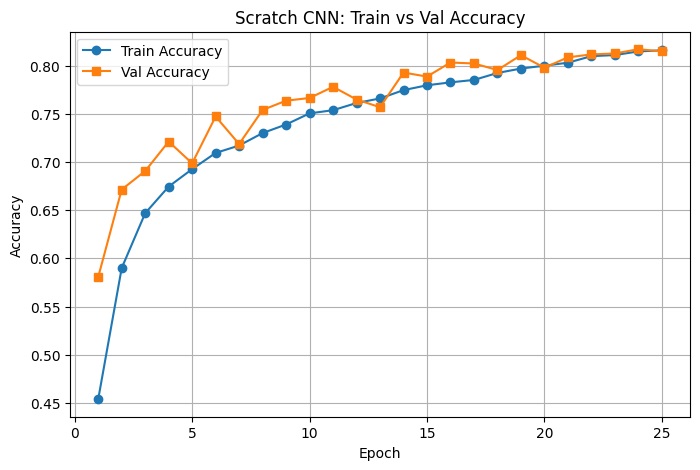

In [ ]:
#plotting train and val accuracy
epochs_range = range(1, len(scratch_history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, scratch_history["train_acc"], label="Train Accuracy", marker='o')
plt.plot(epochs_range, scratch_history["val_acc"], label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Scratch CNN: Train vs Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# **Transfer learning using ResNet-18**

In [ ]:
# ResNet-18 was trained on ImageNet with 224x224 images and ImageNet's own normalization stats
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

transfer_train_transform = transforms.Compose([
    transforms.Resize(224),                  # upscale 32x32 -> 224x224
    transforms.RandomCrop(224, padding=8),   # augmentation, same idea as before
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transfer_eval_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load train data twice (augmented + plain), same pattern as the scratch CNN setup
transfer_full_train_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                          download=True, transform=transfer_train_transform)
transfer_full_train_plain = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                            download=True, transform=transfer_eval_transform)

transfer_test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                    download=True, transform=transfer_eval_transform)

# IMPORTANT: reuse the exact same train_indices/val_indices from Cell 2
# so both models are trained/validated on identical images -> fair comparison
transfer_train_set = Subset(transfer_full_train_aug, train_indices)
transfer_val_set = Subset(transfer_full_train_plain, val_indices)

# Smaller batch size than before (64 instead of 128) since 224x224 images use much more GPU memory than 32x32
transfer_train_loader = DataLoader(transfer_train_set, batch_size=64, shuffle=True, num_workers=2)
transfer_val_loader = DataLoader(transfer_val_set, batch_size=64, shuffle=False, num_workers=2)
transfer_test_loader = DataLoader(transfer_test_set, batch_size=64, shuffle=False, num_workers=2)

print(f"Transfer train size: {len(transfer_train_set)}, "
      f"Val size: {len(transfer_val_set)}, Test size: {len(transfer_test_set)}")

Transfer train size: 45000, Val size: 5000, Test size: 10000


In [ ]:
# Load ResNet-18 pretrained on ImageNet
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all pretrained layers - we only train the new final layer (feature extraction approach)
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer: 512 -> 1000 (ImageNet classes) becomes 512 -> 10 (CIFAR-10 classes)
# This new layer is NOT frozen - it starts randomly initialized and will be trained
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

resnet = resnet.to(device)

# Sanity check: confirm only the new fc layer has trainable parameters
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in resnet.parameters())
print(f"Trainable params: {trainable_params:,} / Total params: {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]

Trainable params: 5,130 / Total params: 11,181,642


In [ ]:
transfer_criterion = nn.CrossEntropyLoss()
# Only the fc layer's parameters need an optimizer, since everything else is frozen
transfer_optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=0.001)

TRANSFER_EPOCHS = 8
transfer_history = {"train_acc": [], "val_acc": []}

for epoch in range(TRANSFER_EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet, transfer_train_loader, transfer_criterion, transfer_optimizer)
    val_loss, val_acc = evaluate(resnet, transfer_val_loader, transfer_criterion)  # validation, not test

    transfer_history["train_acc"].append(train_acc)
    transfer_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{TRANSFER_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# Test set touched ONCE, only after training is fully complete
test_loss, test_acc = evaluate(resnet, transfer_test_loader, transfer_criterion)
transfer_final_acc = test_acc
print(f"\nTransfer Learning FINAL TEST accuracy: {transfer_final_acc:.4f}")

Epoch 1/8 | Train Loss: 0.8628 Acc: 0.7245 | Val Loss: 0.6322 Acc: 0.7776
Epoch 2/8 | Train Loss: 0.6310 Acc: 0.7867 | Val Loss: 0.6218 Acc: 0.7814
Epoch 3/8 | Train Loss: 0.5991 Acc: 0.7942 | Val Loss: 0.5816 Acc: 0.7982
Epoch 4/8 | Train Loss: 0.5823 Acc: 0.7972 | Val Loss: 0.5860 Acc: 0.7930
Epoch 5/8 | Train Loss: 0.5745 Acc: 0.8018 | Val Loss: 0.5523 Acc: 0.8070
Epoch 6/8 | Train Loss: 0.5650 Acc: 0.8030 | Val Loss: 0.5695 Acc: 0.7956
Epoch 7/8 | Train Loss: 0.5656 Acc: 0.8050 | Val Loss: 0.5626 Acc: 0.8090
Epoch 8/8 | Train Loss: 0.5620 Acc: 0.8076 | Val Loss: 0.5468 Acc: 0.8064

Transfer Learning FINAL TEST accuracy: 0.8058


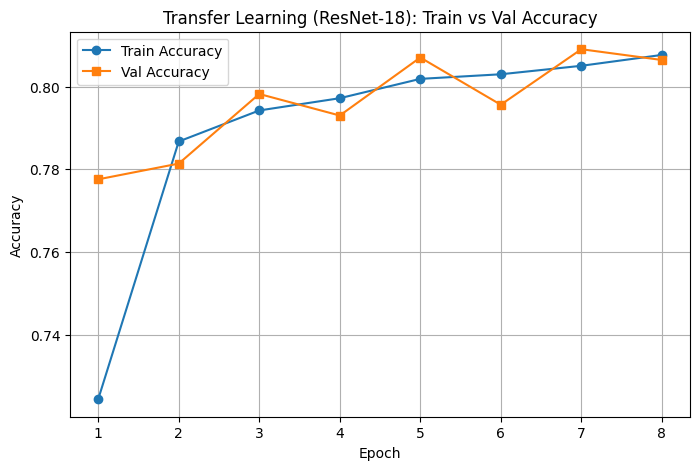

In [ ]:
#plotting train and val accuracy
epochs_range = range(1, len(transfer_history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, transfer_history["train_acc"], label="Train Accuracy", marker='o')
plt.plot(epochs_range, transfer_history["val_acc"], label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning (ResNet-18): Train vs Val Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# **Comparison between scratch CNN and ResNet**

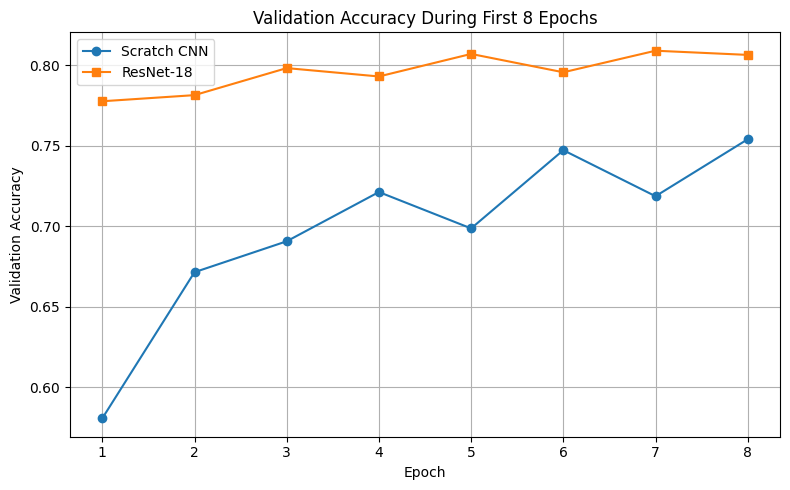

In [ ]:
#validation accuracy comparison during first 8 epochs
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 9),
    scratch_history["val_acc"][:8],
    marker="o",
    label="Scratch CNN"
)

plt.plot(
    range(1, 9),
    transfer_history["val_acc"][:8],
    marker="s",
    label="ResNet-18"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy During First 8 Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


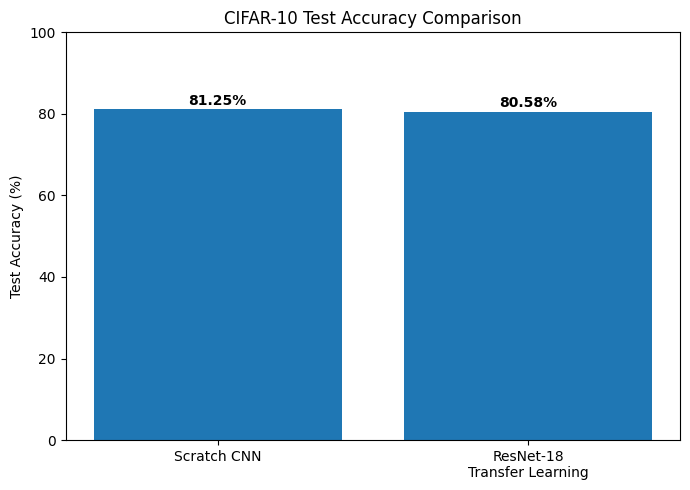

In [ ]:
# Final Test Accuracy Comparison

models = ["Scratch CNN", "ResNet-18\nTransfer Learning"]
accuracies = [
    scratch_final_acc * 100,
    transfer_final_acc * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("CIFAR-10 Test Accuracy Comparison")
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# **Visualizing conv filter activations**

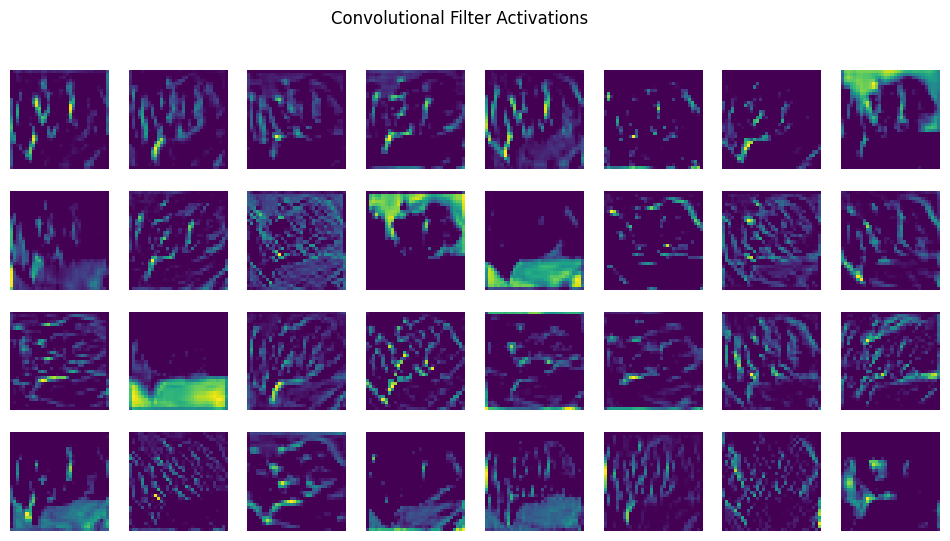

In [ ]:
image, label = test_set[0]

x = image.unsqueeze(0).to(device)

scratch_model.eval()

with torch.no_grad():
    activation = scratch_model.relu(
        scratch_model.bn1(
            scratch_model.conv1(x)
        )
    )

activation = activation.squeeze(0).cpu()

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(activation[i], cmap="viridis")
    ax.axis("off")

plt.suptitle("Convolutional Filter Activations")
plt.show()

## Summary

Built a CNN from scratch for CIFAR-10 classification, achieving **81.25% test accuracy** after tuning
(dropout 0.2, 25 epochs, LR scheduler). Applied transfer learning using a frozen pretrained ResNet-18
backbone with only the final layer trained, achieving **80.58% test accuracy** — slightly below the
scratch model, likely due to the domain gap between ResNet-18's ImageNet-trained features (sharp,
high-resolution photos) and CIFAR-10's low-resolution images upscaled to 224×224. Filter and activation
visualizations of the scratch CNN confirmed the expected edge → texture → pattern hierarchy across
conv1, conv2, and conv3 layers, with deeper layers producing increasingly abstract, compressed feature
maps. Full fine-tuning of the ResNet-18 backbone was left for later exploration alongside LoRA/PEFT
techniques in the Generative AI/LLM section.